In [267]:
import numpy as np
import matplotlib.pyplot as plt

Thermodynamics & dynamics of parcel moving vertically through an environment

In [268]:
# Function to compute saturation vapor pressure (Pa) from temperaure (K) (Petty eqn 7.19)
# Input is temperature in K
def e_s(T):
  T_C = T - 273.15 #T in deg C
  e = 611.2 * np.exp(17.67*T_C/(T_C+243.5))
  return e

In [269]:
# Function to compute specific humidity from pressure (Pa) and vapor pressure (Pa)
# (Petty eqn 3.41)
# Inputs are vapor pressure and pressure in Pa
def q(e,p):
  epsilon = 0.622 # Ratio of molecular weights, water vapor/dry air
  q = epsilon*e/(p - (1.-epsilon)*e)
  return q

In [270]:
v_init = 10.
gamma_init = 8. # K/km
T_dew_dep_init = 0. # K was 5

In [271]:
# Establish environment with surface pressure, p_surf, & lapse rate, Gamma

#Constants
R_dry = 287.05 #gas constant dry air: J/kg/K
c_p = 1004 #specific heat of dry air at constant pressure: J/kg/K
g = 9.81 #acceleration of gravity: m/s^2
T_0C = 273.15 #temperature at 0 deg C: K
L = 2.5e6 # latent heat of condensation: J/kg

#Vertical grid
n_z = 20000 #number vertical gridpoints
delta_z = 1. #vertical grid spacing: m
z_max = n_z * delta_z
z=np.linspace(0.,z_max,n_z) #vertical grid

#Temperature profile: constant lapse rate up to 10 km, "stratosphere" above 10 km
T_env=np.zeros(n_z)
T_surf = 20. #surface temperature: deg C
T_surf = T_surf + T_0C
Gamma = gamma_init #lapse rate: K/km
Gamma = Gamma/1000. #convert to K/m
z_trop = 10.e3 #tropopause height in m

for i_z in range(0,n_z):
  if z[i_z] <= z_trop:
    T_env[i_z] = T_surf - Gamma*z[i_z]
  else:
    T_env[i_z] = T_surf - Gamma*z_trop

#Obtain environmental pressure profile from integrating hydrostaic equation
g_d_Rdz = g/R_dry*delta_z
p = np.zeros(n_z)
p_surf = 101325 #surface pressure: Pa
p_0 = 1.e5 #reference pressure: Pa
p[0] = p_surf
for i_z in range(1,n_z):
  T_m = .5*(T_env[i_z]+T_env[i_z-1])
  p[i_z] = p[i_z-1]*(1-.5*g_d_Rdz/T_m)/(1.+.5*g_d_Rdz/T_m)

# Integrate 1st law and vertical momentume equation to obtain time evolution w, q, z, & T

#Time step and time arrays
delta_t=0.05 #time step: s
n_t = 30000 #number of timesteps
t=np.linspace(0.,(n_t-1)*delta_t,n_t)
z_parcel=np.zeros(n_t)
p_parcel=np.zeros(n_t)
T_parcel=np.zeros(n_t)
T_env_local=np.zeros(n_t)
q_parcel=np.zeros(n_t)
theta_parcel=np.zeros(n_t)
w_parcel=np.zeros(n_t)

#Initial altitude, pressure, temperature, & vertical velocity
z_0 = 1. #initial altitude: km
z_0 = z_0 * 1000. #initial altitude: m
z_parcel[0] = z_0
p_parcel[0] = np.interp(z_parcel[0],z,p)
T_pert = 0. #initial perturbation temperature: K
T_env_local[0] = np.interp(z_parcel[0],z,T_env)
T_parcel[0] = T_env_local[0] + T_pert
theta_parcel[0]=T_parcel[0]*(p_0/p_parcel[0])**(R_dry/c_p)
w_parcel[0] = v_init # initial vertical velocity: m/s
T_dew_dep = T_dew_dep_init # initial dewpoint depression: K
T_dew = T_parcel[0] - T_dew_dep

#Initial specific humidity and virtual temperature
e = e_s(T_dew) #vapor pressure = saturation vapor pressure at dewpoint T: Pa
q_parcel[0] = q(e,p_parcel[0]) #initial specific humidity: nondimensional
T_v = (1+.61*q_parcel[0])*T_parcel[0] #Approxiamte virtual temperature: K

delta_q=0. #for first step assume no condensation

#Integrate 1st law of thermodynamics
for i_t in range(1,n_t):
  z_parcel[i_t] = z_parcel[i_t-1] + w_parcel[i_t-1]*delta_t #update parcel altitude: m
  p_parcel[i_t] = np.interp(z_parcel[i_t],z,p) #update parcel pressure (= p_env): Pa
  delta_p = p_parcel[i_t]-p_parcel[i_t-1] #change in pressure from previous time

  #Update temperature using 1st law: adiabatic compresssion + latent heating
  T_parcel[i_t] = T_parcel[i_t-1]*\
   (1.+ .5*R_dry*delta_p/p_parcel[i_t-1]/c_p)\
   /(1.- .5*R_dry*delta_p/p_parcel[i_t]/c_p)\
    + delta_q*L/c_p

  #Update virtual temperature
  T_v = (1+.61*q_parcel[i_t])*T_parcel[i_t]

  #Get buoyant acceleration and update vertical velocity: m/s
  T_env_local[i_t] = np.interp(z_parcel[i_t],z,T_env)
  w_parcel[i_t] =  w_parcel[i_t-1]\
  +g*delta_t*(T_v-T_env_local[i_t])/T_env_local[i_t]

  #Update q
  #Find q_s at new T
  e_sat= e_s(T_parcel[i_t])
  q_s= q(e_sat,p_parcel[i_t])

  #If parcel is oversaturated, find delta_q needed to restore saturation
  #Restore saturation and save delta_q for 1st law calculation (above)
  if q_parcel[i_t-1] <= q_s:
    q_parcel[i_t]= q_parcel[i_t-1]
    delta_q=0.
  else:
    delta_q = q_parcel[i_t-1] - q_s
    q_parcel[i_t] = q_s

  #Track parcel potential temperature
  theta_parcel[i_t]=T_parcel[i_t]*(p_0/p_parcel[i_t])**(R_dry/c_p)

print('Initial theta',theta_parcel[0])
print('Final theta',theta_parcel[n_t-1])

#Compute CAPE from maximum and initial w

w_max = np.amax(w_parcel)
CAPE = .5*(w_max**2 - w_parcel[0]**2)

print('CAPE=',CAPE,'J/kg')


Initial theta 293.84261532886245
Final theta 321.9178699011972
CAPE= 2611.638638181905 J/kg


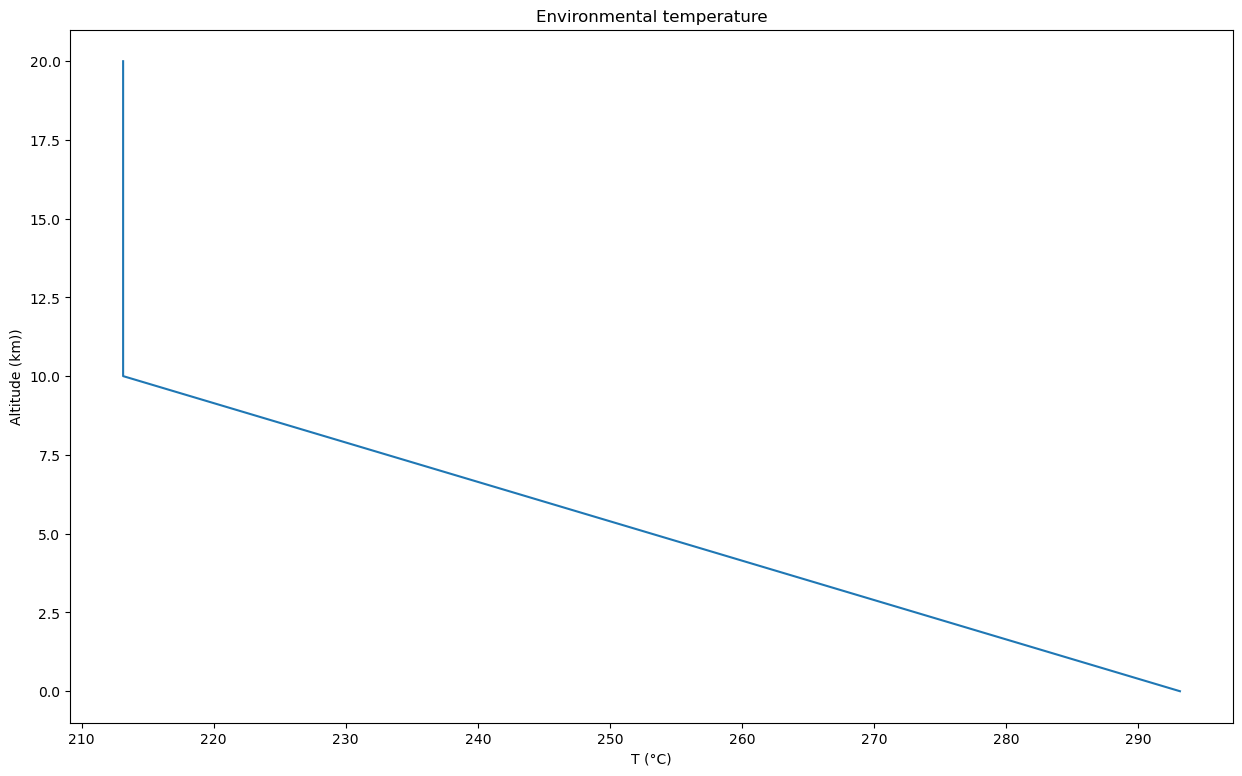

In [272]:
#Plots
# Figure Size (Default is too small)
plt.rcParams["figure.figsize"] = (15, 9)

#Environmental temperature profile
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.set_ylabel('Altitude (km))')
ax1.set_xlabel('T (°C)')
ax1.set_title('Environmental temperature')
line, = ax1.plot(T_env,z/1000. )
plt.savefig('environmental_temperature'+str(v_init)+'_gamma'+str(gamma_init)+'.png')
plt.show()

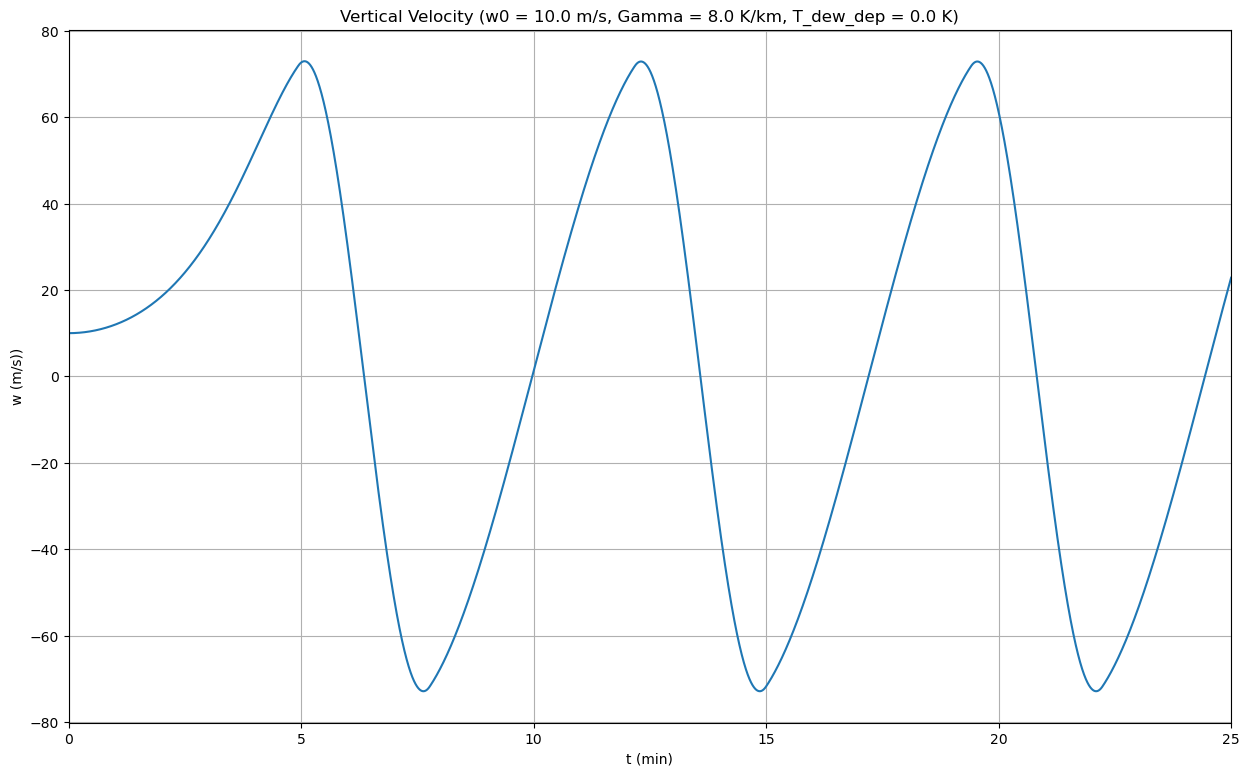

In [273]:
#Vertical velocity
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.set_ylabel('w (m/s))')
ax1.set_xlabel('t (min)')
ax1.set_title('Vertical Velocity (w0 = '+str(v_init)+' m/s, Gamma = '+str(gamma_init)+' K/km, T_dew_dep = '+str(T_dew_dep_init)+' K)')
line, = ax1.plot(t/60.,w_parcel)
plt.grid()
plt.xlim(0, 25)
plt.savefig('vertical_velocity'+str(v_init)+'_gamma'+str(gamma_init)+'_T_dew_dep'+str(T_dew_dep_init)+'.png')
plt.show()

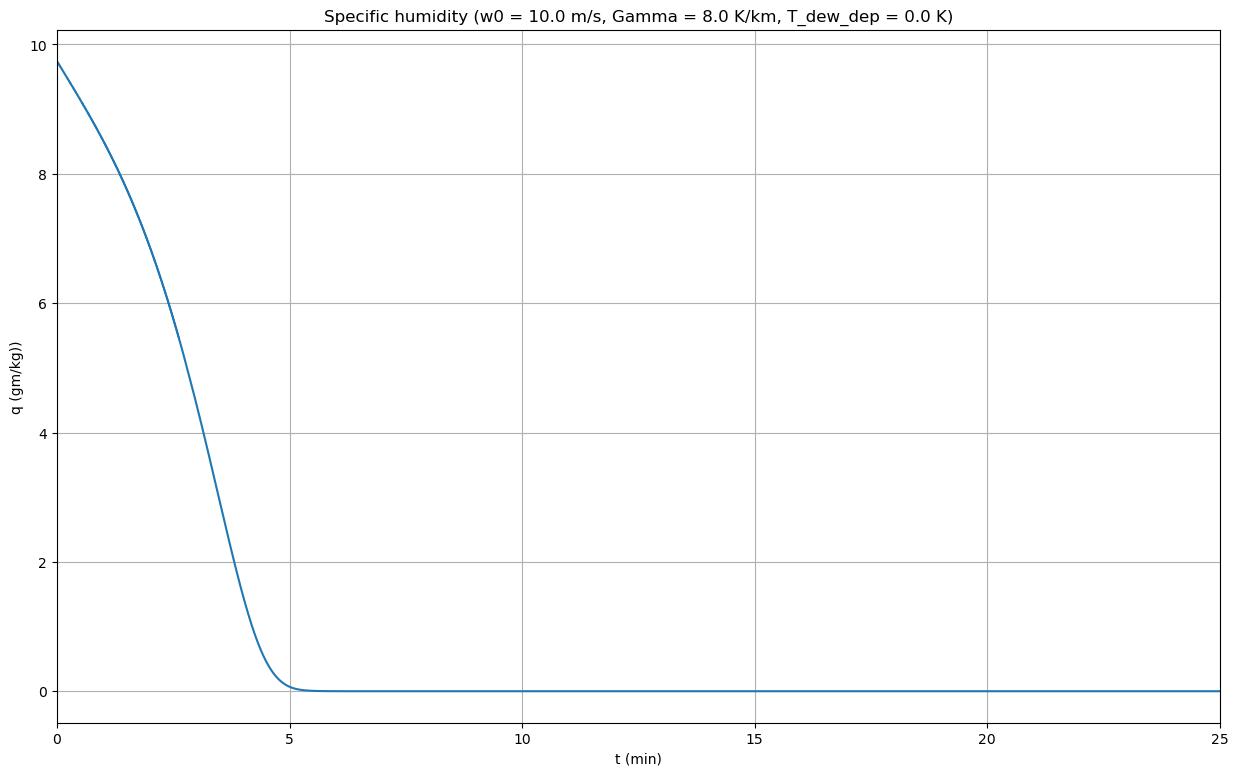

In [274]:
#Parcel specific humidity
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.set_ylabel('q (gm/kg))')
ax1.set_xlabel('t (min)')
ax1.set_title('Specific humidity (w0 = '+str(v_init)+' m/s, Gamma = '+str(gamma_init)+' K/km, T_dew_dep = '+str(T_dew_dep_init)+' K)')
line, = ax1.plot(t/60.,q_parcel*1000.)
plt.xlim(0, 25)
plt.grid()
plt.savefig('specific_humidity'+str(v_init)+'_gamma'+str(gamma_init)+'_T_dew_dep'+str(T_dew_dep_init)+'.png')
plt.show()

In [275]:
line, = ax1.plot(t/60., q_parcel*1000.)
# detect first significant change from initial value
tol = 1e-6
diff_idx = np.where(np.abs(q_parcel - q_parcel[0]) > tol)[0]
if diff_idx.size > 0:
    i_change = diff_idx[0]
    t_change_min = t[i_change]/60.  # minutes
    ax1.axvline(t_change_min, color='r', linestyle='--', label=f'change at {t_change_min:.2f} min')
    ax1.legend()
    print(f'q_parcel first changes at t = {t_change_min:.2f} min (index {i_change})')
else:
    print('q_parcel remained constant within tolerance')

q_parcel first changes at t = 0.00 min (index 1)


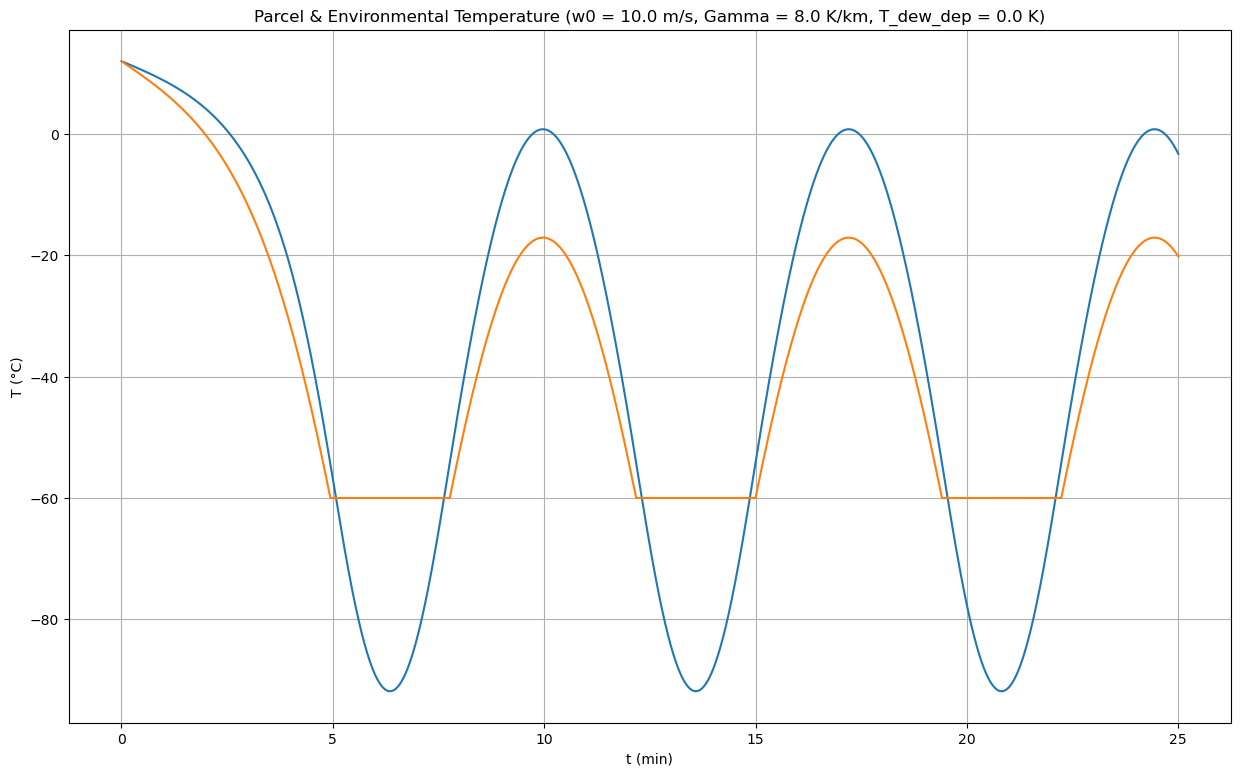

In [276]:
#Parcel & environmental temperature versus time
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.set_ylabel('T (°C)')
ax1.set_xlabel('t (min)')
ax1.set_title('Parcel & Environmental Temperature (w0 = '+str(v_init)+' m/s, Gamma = '+str(gamma_init)+' K/km, T_dew_dep = '+str(T_dew_dep_init)+' K)')
line, = ax1.plot(t/60.,T_parcel-T_0C)
line, = ax1.plot(t/60.,T_env_local-T_0C)
plt.grid()
plt.savefig('temperature_time_series'+str(v_init)+'_gamma'+str(gamma_init)+'.png')
plt.show()

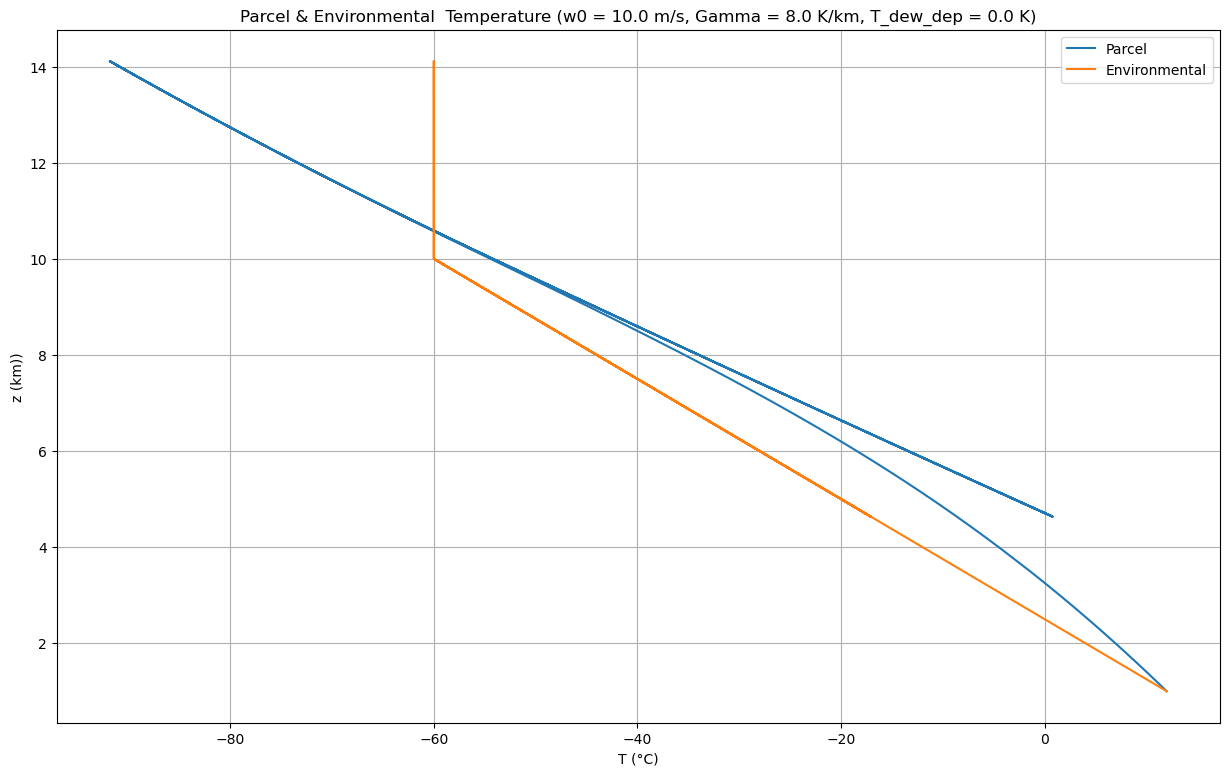

In [277]:
#Parcel & environmental temperature versus altitude
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('z (km))')
ax2.set_xlabel('T (°C)')
ax2.set_title('Parcel & Environmental  Temperature (w0 = '+str(v_init)+' m/s, Gamma = '+str(gamma_init)+' K/km, T_dew_dep = '+str(T_dew_dep_init)+' K)')
line, = ax2.plot(T_parcel-T_0C,z_parcel/1000., label='Parcel')
line, = ax2.plot(T_env_local-T_0C,z_parcel/1000., label='Environmental')
plt.grid()
plt.legend(loc='upper right')
plt.savefig('vertical_temperature'+str(v_init)+'_gamma'+str(gamma_init)+'_T_dew_dep'+str(T_dew_dep_init)+'.png')
plt.show()

In [278]:
tol = 1e-9
# saturation specific humidity at parcel T & p
e_sat = e_s(T_parcel)                 # vectorized if e_s accepts array
q_s = q(e_sat, p_parcel)
# primary: use first index where q_parcel departs from initial value
idx_q_change = np.where(np.abs(q_parcel - q_parcel[0]) > tol)[0]
if idx_q_change.size > 0:
    i_lcl = idx_q_change[0]
else:
    # fallback: find first index where q_parcel equals q_s (within tolerance)
    idx_eq = np.where(np.isclose(q_parcel, q_s, rtol=1e-6, atol=1e-12))[0]
    i_lcl = idx_eq[0] if idx_eq.size>0 else None

if i_lcl is not None:
    z_lcl_km = z_parcel[i_lcl] / 1000.0
    print(f'LCL at index {i_lcl}, z = {z_lcl_km:.3f} km')
    ax2.axhline(z_lcl_km, color='r', linestyle='--', label=f'LCL {z_lcl_km:.3f} km')
    ax2.plot(T_parcel[i_lcl]-T_0C, z_lcl_km, 'ro')
    ax2.legend()
else:
    print('LCL not detected')

LCL at index 1, z = 1.000 km


In [279]:
tol_LFC = 1e-6
start_idx = i_lcl if 'i_lcl' in globals() and i_lcl is not None else 0
mask = np.where((T_parcel - T_env_local) > tol_LFC)[0]
lfc_idx = next((idx for idx in mask if idx >= start_idx), None)
if lfc_idx is not None:
    z_lfc_km = z_parcel[lfc_idx] / 1000.0
    ax2.axhline(z_lfc_km, color='m', linestyle='--', label=f'LFC {z_lfc_km:.3f} km')
    ax2.plot(T_parcel[lfc_idx]-T_0C, z_lfc_km, 'm^')
    ax2.legend()
    print(f'LFC at index {lfc_idx}, z = {z_lfc_km:.3f} km')
else:
    print('LFC not found')

LFC at index 2, z = 1.001 km


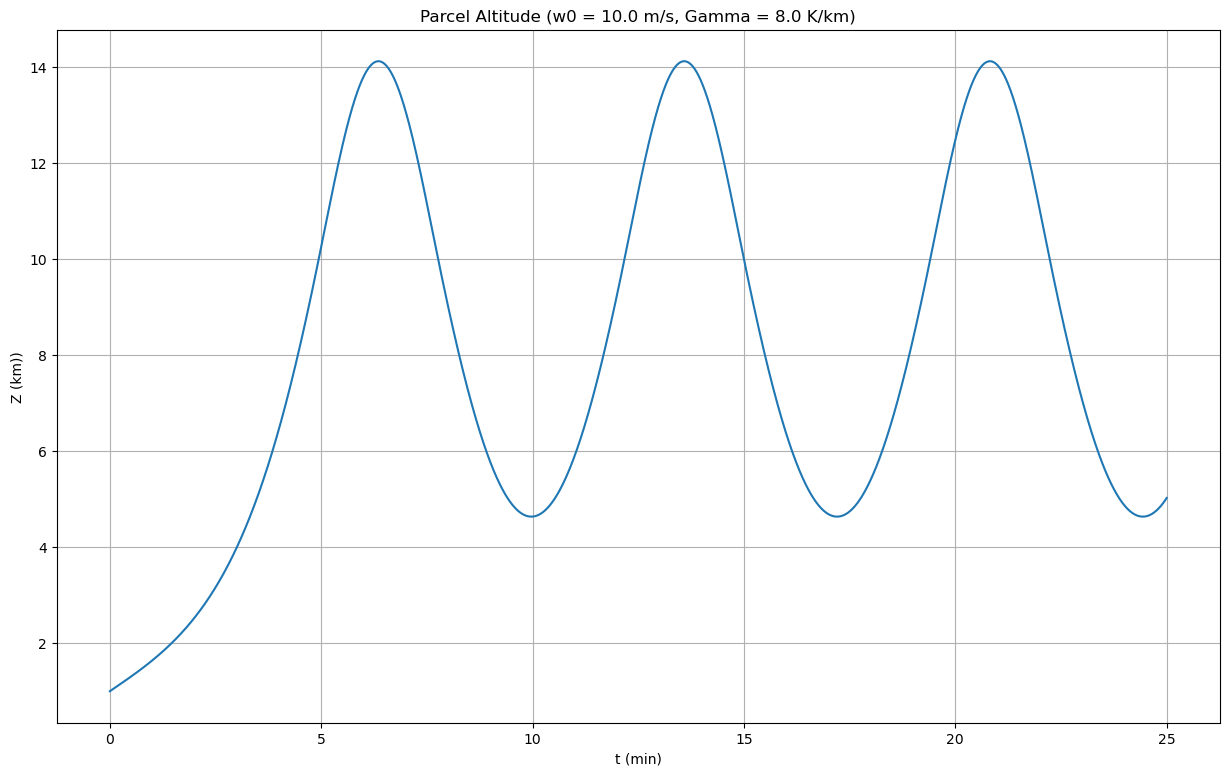

In [280]:
#Parcel altitude
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.set_ylabel('Z (km))')
ax1.set_xlabel('t (min)')
ax1.set_title('Parcel Altitude (w0 = '+str(v_init)+' m/s, Gamma = '+str(gamma_init)+' K/km)')
line, = ax1.plot(t/60.,z_parcel/1000.)
plt.grid()
plt.savefig('parcel_altitude_w'+str(v_init)+'_gamma'+str(gamma_init)+'.png')
plt.show()

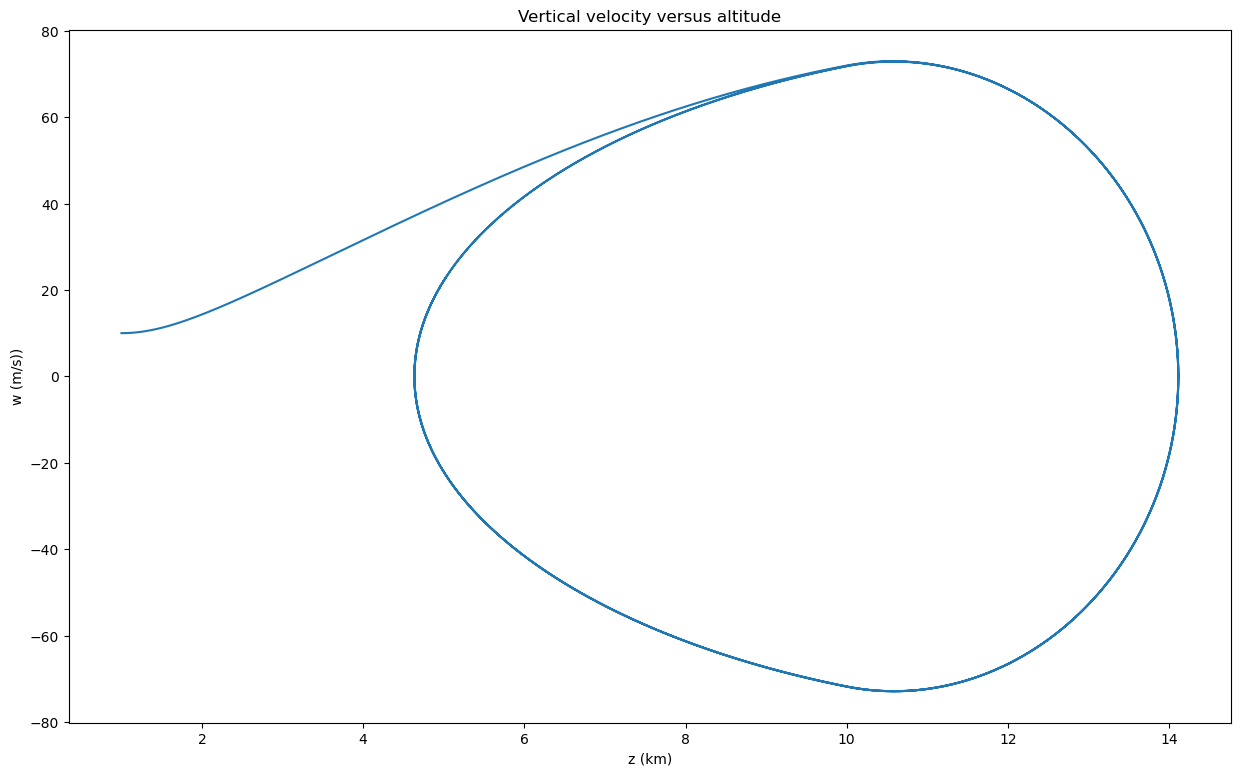

In [281]:
#Parcel altitude
fig = plt.figure()
ax3 = fig.add_subplot(111)
ax3.set_ylabel('w (m/s))')
ax3.set_xlabel('z (km)')
ax3.set_title('Vertical velocity versus altitude')
line, = ax3.plot(z_parcel/1000,w_parcel)
plt.show()

In [286]:
10 + 10.3

20.3